![hslu_logo.png](img/hslu_logo.png)

## Week 3

<hr style="border:1px solid black">


# Excercise: Convolutional Neural Network using PyTorch
---
---
This excercise is to illustrate a classification problem using a convolutional neural network (cnn). The input data can be choosen to be MNIST, FashionMNIST or CIFAR10

### Import necessary packages

In [31]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import time

from utils import read_data_orig, plot_img, plot_tiles, plot_error, plot_cost

#### Download dataset (MNIST, FashionMNIST or CIFAR10)

In [32]:
#data is saved in storage_path (use same path for different SW)
#MNIST, FashionMNIST or CIFAR10
training_data, test_data, labels_map = read_data_orig('FashionMNIST', storage_path='../SW01/data') 

if len(training_data.data.shape) == 3:
    training_data.data = training_data.data.unsqueeze(1)
    test_data.data = test_data.data.unsqueeze(1)

num_images_planes = training_data.data.shape[1]


print('converted data types')
print(training_data.data.shape)

converted data types
torch.Size([60000, 1, 28, 28])


#### plot sample images

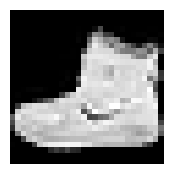

In [33]:
plot_img(torch.movedim(training_data.data[0], [0],[2]), figure_size = [2,2])

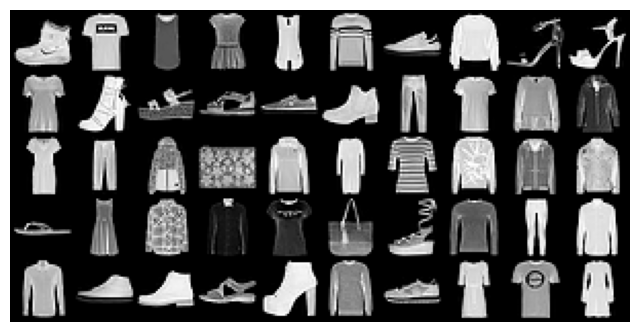

In [34]:
#plot categories mixed
plot_tiles(training_data.data, 10,5)

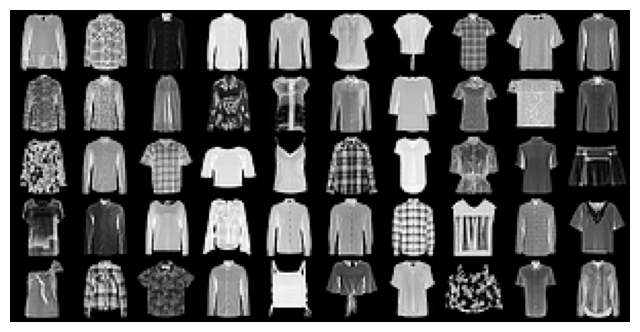

In [35]:
#plot only certain categorie
label = 6
plot_tiles(training_data.data[training_data.targets == label], 10,5)

#### MiniBatch class
Pytorch has its own dataloader routine for mini batches but the present version is more efficient for our toy model

In [36]:
class MiniBatches:
    """
    obtains x- and y-data in the constructor and returns a sample of batch_size with each call to next()
    """
    def __init__(self, X, Y, batch_size):
        """
        constructor

        Arguments:
        x/y -- data
        batch_size -- size of batch (0 means one single batch)
        """
        self.X = X
        self.Y = Y
        m = X.shape[0]
        self.indices = torch.randperm(m)
        self.n = X.shape[1]
        
        if not batch_size:
            self.batch_size = m
            self.mb = 1
        else:
            self.batch_size = batch_size        
            self.mb = int(m / self.batch_size)    
        
        self.ib = 0

    def number_of_batches(self):
        return self.mb

    def next(self):
        it = self.indices[self.ib * self.batch_size:(self.ib + 1) * self.batch_size]
        X_batch = self.X[it, :]
        Y_batch = self.Y[it]
        self.ib += 1

        return {'X_batch': X_batch, 'Y_batch': Y_batch}

#### Define the neural network

In [40]:
class ConvNeuralNetwork:
    """
    MLP class handling the layers and doing all prop and back_prop steps
    we assume all hidden layers to be dense (with sigmoid activation) and the last layer to be softmax
    """
    def __init__(self, size_in, list_conv_layer, list_num_neurons):
        """
        constructor

        Arguments:
        size_in -- size of input image
        list_conv_layer -- list of convolutional layers [number of layers, square filter size], each followed by 2x2 max pooling 
        list_num_neurons -- list of fully connvected layer sizes including output layer
        
        """

        self.model = torch.nn.Sequential()

        next_size = size_in
        layer_c = 0

### START YOUR CODE ###
        #first construct conv layers (conv + activtion + pooling)
        for i0 in range(len(list_conv_layer)):
            self.model.add_module('conv' + str(layer_c), torch.nn.Conv2d(in_channels=next_size[0],
                                                                          out_channels=list_conv_layer[i0][0],
                                                                          kernel_size=list_conv_layer[i0][1], 
                                                                          padding="same"))
            self.model.add_module('act' + str(layer_c), torch.nn.ReLU())
            self.model.add_module('pool' + str(layer_c), torch.nn.MaxPool2d(2))  

            next_size = [list_conv_layer[i0][0], next_size[1] // 2, next_size[2] // 2]
            layer_c += 1
    
        #now we have to flatten the data;
        self.model.add_module('flatten', torch.nn.Flatten()) 

        num_flatten = next_size[0] * next_size[1] * next_size[2]
        list_num_neurons = [num_flatten] + list_num_neurons
        # list_num_neurons = [1568] + list_num_neurons
        print(list_num_neurons)
            
        #now add other dense layers (if any)
        for i0 in range(0,len(list_num_neurons)-2):
            self.model.add_module(f'fc{layer_c}', torch.nn.Linear(list_num_neurons[i0], list_num_neurons[i0 + 1]))
            self.model.add_module('act' + str(layer_c), torch.nn.ReLU())
            layer_c += 1
      
        #finally add softmax layer
        self.model.add_module('fc' + str(layer_c), torch.nn.Linear(list_num_neurons[-2], list_num_neurons[-1]))
        #we don't require softmax layer because it is included (for numerical reasons) in the cross entropy cost below
        #alternative is logSoftmax together with NLLLoss cost function
        #self.model.add_module('sofmax' + str(layer_c), torch.nn.Softmax(dim=1))   

### END YOUR CODE ###
                
        self.cost_fn = torch.nn.CrossEntropyLoss(reduction='mean')

        #used to save results
        self.result_data = torch.tensor([])
        
    def propagate(self, X):
        """
        calculates the function estimation based on current parameters [W,B]
        """    
        self.Y_pred = self.model(X)
           
     
    def back_propagate(self, cost):
        """
        calculates the backpropagation results based on expected output y
        this function must be performed AFTER the corresponding propagte step
        """    
        self.model.zero_grad()
        
        cost.backward()
 

    def calc_cost(self, Y):
        """
        calculates the MSE loss function
        """
        cost = self.cost_fn(self.Y_pred, Y)
        
        return cost
    
        
        
    def gradient_descend(self, alpha):
        """
        does the gradient descend based on results from last back_prop step with learning rate alpha
        """
        with torch.no_grad():
            for param in self.model.parameters():
                param -= alpha * param.grad
            
     
        
    def calc_error(self, Y):
        """
        get error information
        """
        m = Y.shape[0]

        Y_pred_argmax = torch.argmax(self.Y_pred, dim=1)
        train_error = torch.sum(Y != Y_pred_argmax) / m

        return train_error


    def save_training_data(self, data):
        """
        save training and validation curves
        """
        #determine the train loss and error
        self.propagate(data['X_train'])
        cost_train = self.calc_cost(data['Y_train'])
        error_train = self.calc_error(data['Y_train'])
        #calculate validation loss and error
        self.propagate(data['X_val'])
        cost_val = self.calc_cost(data['Y_val'])
        error_val = self.calc_error(data['Y_val'])

        #safe the results
        res = torch.tensor([[cost_train.item(), error_train.item(), cost_val.item(), error_val.item()]])
        self.result_data = torch.cat((self.result_data, res), 0)
        
        
    def optimize(self, data, epochs, alpha, batch_size=16, debug=0):
        """
        performs epochs number of gradient descend steps and appends result to output array

        Arguments:
        data -- dictionary with data
        epochs -- number of epochs
        alpha -- learning rate
        batch_size -- size of batch (0: use full training set)
        debug -- False (default)/True; get info on each gradient descend step
        """
        
        # save results before 1st step
        for i0 in range(0, epochs):
            #save the data at the beginning of the step
            self.save_training_data(data)
            #create batches for each epoch
            batches = MiniBatches(data['X_train'], data['Y_train'], batch_size)
            #loop over batches
            for ib in range(batches.number_of_batches()):
                batch = batches.next()
                #do prediction
                self.propagate(batch['X_batch'])
                #determine the loss 
                cost = self.calc_cost(batch['Y_batch'])
                #determine the error
                self.back_propagate(cost)
                #do the correction step
                self.gradient_descend(alpha)
            
            if debug and np.mod(i0, debug) == 0:
                print('step %r, train cost %1.3f, train error %1.3f, val cost %1.3f, val error %1.3f' % \
                      (i0, self.result_data[-1,0], self.result_data[-1,1], self.result_data[-1,2], self.result_data[-1,3]))
                        
        #save final performance
        self.save_training_data(data)

#### Plot result of training 

In [41]:
#normalize data: original data is overwritten
data_min, data_max = torch.min(training_data.data), torch.max(training_data.data)
print('original min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))

normalize_tpye = 0

if normalize_tpye == 0:
    #min-max-rescaling
    training_data.data = (training_data.data.float() - data_min) / (data_max - data_min)    
    test_data.data = (test_data.data.float() - data_min) / (data_max - data_min)   
else:
    #min-max-normalization
    training_data.data = 2*(training_data.data.float() - data_min) / (data_max - data_min) - 1
    test_data.data = 2*(test_data.data.float() - data_min) / (data_max - data_min) - 1 

data_min, data_max = torch.min(training_data.data), torch.max(training_data.data)
print('now min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))


original min-max values are: 0.0, 1.0 and type torch.float32
now min-max values are: 0.0, 1.0 and type torch.float32


#### Define X and Y values and do optimization

[1568, 200, 10]
Sequential(
  (conv0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (act0): ReLU()
  (pool0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (act1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc2): Linear(in_features=1568, out_features=200, bias=True)
  (act2): ReLU()
  (fc3): Linear(in_features=200, out_features=10, bias=True)
)
step 0, train cost 2.302, train error 0.900, val cost 2.301, val error 0.902
step 5, train cost 0.368, train error 0.137, val cost 0.394, val error 0.145
step 10, train cost 0.252, train error 0.092, val cost 0.291, val error 0.104
time for 15 epochs was: 396.2935631275177 s

test error: 0.10239999741315842


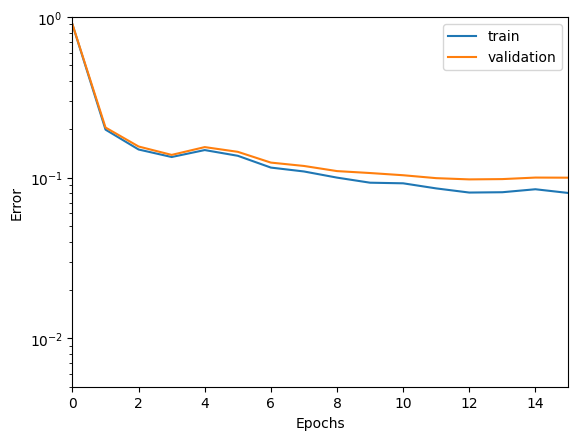

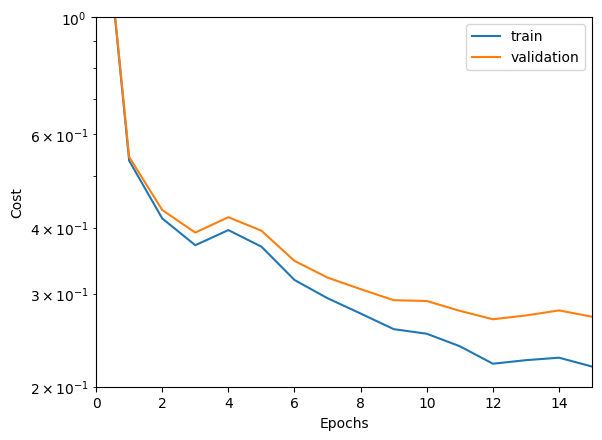

In [42]:
#training data
data_X = training_data.data
#labels are direclty supported by pytorch
data_Y = training_data.targets

#further split in train and validation data
validation_size = 0.2
valid_ind = int(len(data_X)*(1-validation_size))

data = {'X_train' : data_X[:valid_ind], 'Y_train' : data_Y[:valid_ind], \
         'X_val' : data_X[valid_ind:], 'Y_val' : data_Y[valid_ind:]}

size_in = data_X[0].shape
list_conv_layer = [[16,5],[32,3]]
num_output = len(torch.unique(data_Y))
list_num_neurons = [200,num_output]

cnn = ConvNeuralNetwork(size_in, list_conv_layer, list_num_neurons)

print(cnn.model)

epochs=5

start=time.time()
cnn.optimize(data, epochs=epochs, alpha=0.01, batch_size=16, debug=5)
end=time.time()
dtime = end-start
print('time for %r epochs was: %r s' % (epochs, dtime))

#determine test error
cnn.propagate(test_data.data)
test_error = cnn.calc_error(test_data.targets)
print('\ntest error:', test_error.item())

plot_error(cnn)
plot_cost(cnn)

### Analyse the number of parameters

Especially observe the ratio of parameters in the convolutional and the dense layers

In [43]:
for name, parameter in cnn.model.named_parameters():
    print(name, parameter.numel())

conv0.weight 400
conv0.bias 16
conv1.weight 4608
conv1.bias 32
fc2.weight 313600
fc2.bias 200
fc3.weight 2000
fc3.bias 10


### Plot the weights of the first conv layer

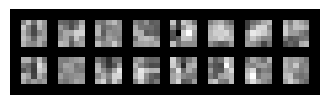

In [44]:
img_grid = torchvision.utils.make_grid(cnn.model[0].weight, normalize = True)
plot_img(torch.movedim(img_grid, [0],[2]), figure_size = [4,4])

### Plot the activations of the conv layers

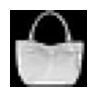

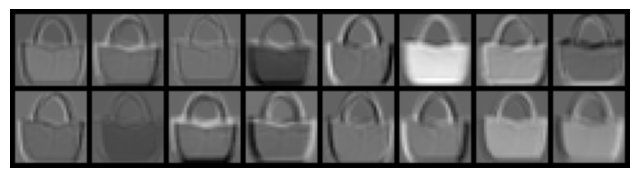

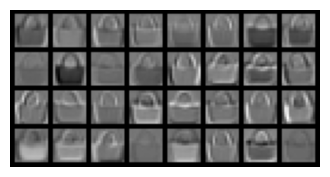

In [45]:
#choose an index
img_index = 100

img=data_X[img_index:img_index+1]
#plot it
plot_img(torch.movedim(img[0], [0],[2]), figure_size = [1,1])

#git activations of first conv layer
activ=cnn.model[0](img)
#plot it                   
img_grid = torchvision.utils.make_grid(activ[0].unsqueeze(1), normalize = True) 
plot_img(torch.movedim(img_grid, [0],[2]), figure_size = [8,8])

#get activations of second conv layer
for i0 in range(1,4):
    activ=cnn.model[i0](activ)
#plot it
img_grid = torchvision.utils.make_grid(activ[0].unsqueeze(1), normalize = True)
plot_img(torch.movedim(img_grid, [0],[2]), figure_size = [4,4])